In [1]:
import pandas as pd
import os
import snowflake.connector
import matplotlib.pyplot as plt


# Recuperar variables de entorno
SNOWFLAKE_ACCOUNT = os.getenv("SNOWFLAKE_ACCOUNT")
SNOWFLAKE_USER = os.getenv("SNOWFLAKE_USER")
SNOWFLAKE_PASSWORD = os.getenv("SNOWFLAKE_PASSWORD")
SNOWFLAKE_WAREHOUSE = os.getenv("SNOWFLAKE_WAREHOUSE")
SNOWFLAKE_DATABASE = os.getenv("SNOWFLAKE_DATABASE")
SNOWFLAKE_SCHEMA = "CLEAN"

# Conectar a Snowflake
conn = snowflake.connector.connect(
    user=SNOWFLAKE_USER,
    password=SNOWFLAKE_PASSWORD,
    account=SNOWFLAKE_ACCOUNT,
    warehouse=SNOWFLAKE_WAREHOUSE,
    database=SNOWFLAKE_DATABASE,
    schema=SNOWFLAKE_SCHEMA
)

print("Conexión a Snowflake establecida con éxito.")


Conexión a Snowflake establecida con éxito.


In [2]:
# Función para cargar una tabla desde Snowflake
def load_table(table_name):
    query = f'SELECT * FROM {os.getenv("SNOWFLAKE_DATABASE")}.CLEAN.{table_name}'
    return pd.read_sql(query, conn)

# Cargar las tablas en DataFrames
dim_aisles_df = load_table("DIM_AISLES")
dim_departments_df = load_table("DIM_DEPARTMENTS")
dim_orders_df = load_table("DIM_ORDERS")
dim_products_df = load_table("DIM_PRODUCTS")
dim_users_df = load_table("DIM_USERS")
fact_orders_df = load_table("FACT_ORDERS")


/tmp/ipykernel_2611/1101113460.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


In [3]:
# Definir un diccionario con las tablas cargadas
tables = {
    "dim_aisles": dim_aisles_df,
    "dim_departments": dim_departments_df,
    "dim_orders": dim_orders_df,
    "dim_products": dim_products_df,
    "dim_users": dim_users_df,
    "fact_orders": fact_orders_df
}

# Imprimir la cantidad de filas y columnas de cada tabla
for table_name, df in tables.items():
    print(f" Dimensión de la tabla '{table_name}':")
    print(f"    Filas: {df.shape[0]}")
    print(f"    Columnas: {df.shape[1]}")
    print("-" * 40)

 Dimensión de la tabla 'dim_aisles':
    Filas: 134
    Columnas: 2
----------------------------------------
 Dimensión de la tabla 'dim_departments':
    Filas: 21
    Columnas: 2
----------------------------------------
 Dimensión de la tabla 'dim_orders':
    Filas: 478952
    Columnas: 7
----------------------------------------
 Dimensión de la tabla 'dim_products':
    Filas: 49694
    Columnas: 4
----------------------------------------
 Dimensión de la tabla 'dim_users':
    Filas: 157437
    Columnas: 1
----------------------------------------
 Dimensión de la tabla 'fact_orders':
    Filas: 4545007
    Columnas: 4
----------------------------------------


1. Comportamiento de compra según día de la semana

/tmp/ipykernel_2611/2528800403.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_by_dow.index, y=orders_by_dow.values, palette="viridis")


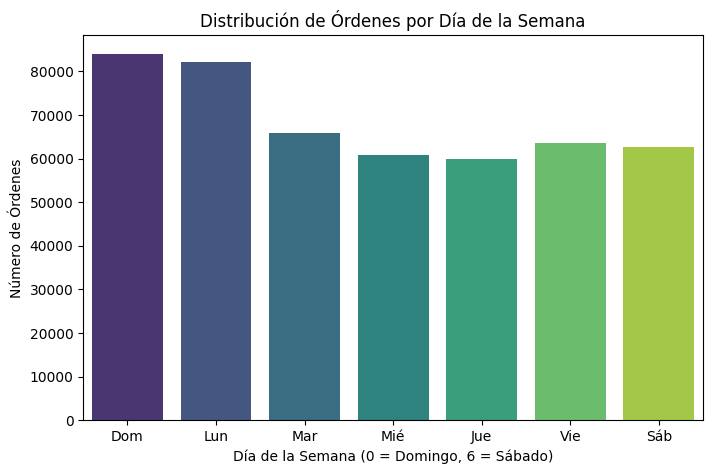

Número de órdenes por día de la semana:
order_dow
0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: count, dtype: int64


In [4]:
import seaborn as sns


# Verificar que la columna 'order_dow' está presente en dim_orders_df
if "order_dow" in dim_orders_df.columns:
    # Contar la cantidad de órdenes por cada día de la semana
    orders_by_dow = dim_orders_df["order_dow"].value_counts().sort_index()

    # Crear el gráfico de barras
    plt.figure(figsize=(8, 5))
    sns.barplot(x=orders_by_dow.index, y=orders_by_dow.values, palette="viridis")

    # Configuración del gráfico
    plt.xlabel("Día de la Semana (0 = Domingo, 6 = Sábado)")
    plt.ylabel("Número de Órdenes")
    plt.title("Distribución de Órdenes por Día de la Semana")
    plt.xticks(ticks=range(7), labels=["Dom", "Lun", "Mar", "Mié", "Jue", "Vie", "Sáb"])
    
    # Mostrar el gráfico
    plt.show()

    # Imprimir los datos en formato tabla
    print("Número de órdenes por día de la semana:")
    print(orders_by_dow)
else:
    print("La columna 'order_dow' no está presente en DIM_ORDERS.")


2. Comportamiento de compra según hora del día

/tmp/ipykernel_2611/2449574804.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_by_hour.index, y=orders_by_hour.values, palette="viridis")


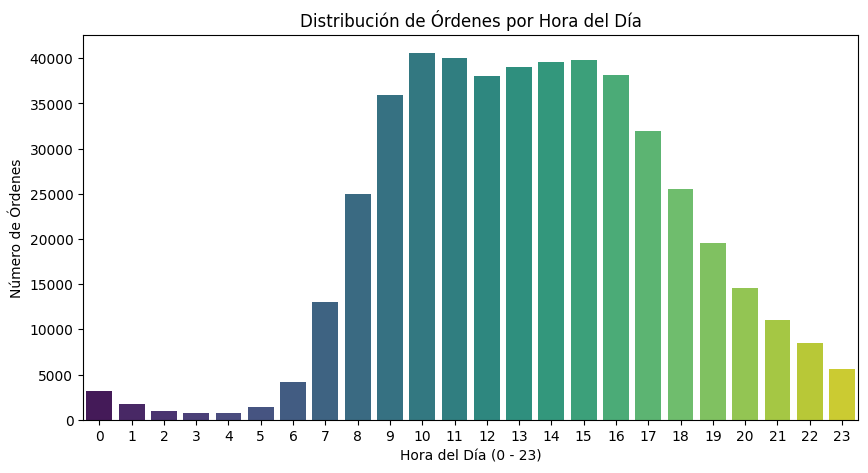

Número de órdenes por hora del día:
order_hour_of_day
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: count, dtype: int64


In [5]:

# Verificar que la columna 'order_hour_of_day' está presente en dim_orders_df
if "order_hour_of_day" in dim_orders_df.columns:
    # Contar la cantidad de órdenes por cada hora del día
    orders_by_hour = dim_orders_df["order_hour_of_day"].value_counts().sort_index()

    # Crear el gráfico de barras
    plt.figure(figsize=(10, 5))
    sns.barplot(x=orders_by_hour.index, y=orders_by_hour.values, palette="viridis")

    # Configuración del gráfico
    plt.xlabel("Hora del Día (0 - 23)")
    plt.ylabel("Número de Órdenes")
    plt.title("Distribución de Órdenes por Hora del Día")
    plt.xticks(ticks=range(24))  # Mostrar todas las horas en el eje X
    
    # Mostrar el gráfico
    plt.show()

    # Imprimir los datos en formato tabla
    print("Número de órdenes por hora del día:")
    print(orders_by_hour)
else:
    print("La columna 'order_hour_of_day' no está presente en DIM_ORDERS.")


3. Comportamiento según hora del día y día de la semana


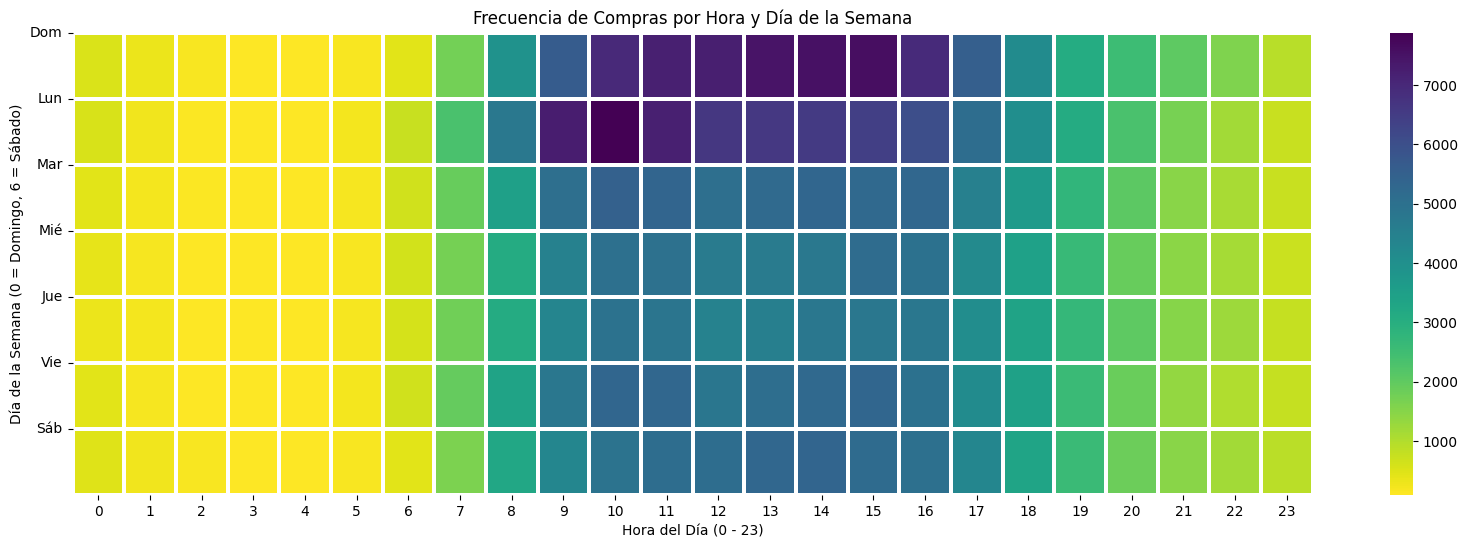

 Frecuencia de órdenes por día y hora:


order_hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
order_dow,,,,,,,,,,,,,,,,,,,,,
0,533,337,188,128,108,171,463,1752,3908,5650,...,7533,7585,6956,5552,4142,3084,2544,2043,1614,921
1,565,269,145,104,104,246,757,2320,4751,7262,...,6545,6446,6050,5125,4075,3126,2332,1698,1165,759
2,462,240,136,104,109,196,653,1900,3485,5057,...,5344,5260,5322,4525,3672,2787,2061,1481,1130,755
3,373,215,106,101,108,170,643,1732,3125,4490,...,4774,5163,4976,4175,3463,2652,1917,1450,1154,718
4,324,229,114,109,100,198,594,1787,3136,4332,...,4795,4795,4788,4089,3379,2691,2037,1506,1236,791
5,459,219,123,99,118,229,654,1933,3373,4794,...,5265,5352,4991,4169,3441,2597,1886,1368,1028,774
6,464,254,177,125,118,161,451,1619,3246,4311,...,5375,5188,5029,4295,3338,2610,1847,1473,1185,893



 Detalle de órdenes para las horas 10, 11, 12 y 13:


order_hour_of_day,10,11,12,13
order_dow,,,,
0,6978,7186,7231,7483
1,7881,7194,6648,6618
2,5489,5365,5066,5234
3,5026,5004,4688,4674
4,4938,4842,4433,4567
5,5347,5325,4836,5108
6,4919,5116,5132,5323


In [6]:

# Verificar que las columnas necesarias están en el DataFrame
if "order_dow" in dim_orders_df.columns and "order_hour_of_day" in dim_orders_df.columns:
    
    # Crear la tabla pivot asegurando que todas las horas del día (0-23) estén presentes
    all_hours = list(range(24))  # Lista con todas las horas
    orders_heatmap = dim_orders_df.pivot_table(
        index="order_dow", 
        columns="order_hour_of_day", 
        values="order_id", 
        aggfunc="count",
        fill_value=0
    ).reindex(columns=all_hours, fill_value=0)  # Asegurar que todas las horas estén en la tabla

    # Crear el heatmap
    plt.figure(figsize=(20, 6))
    sns.heatmap(orders_heatmap, cmap="viridis_r", annot=False, fmt="d", linewidths=1.5)

    # Configuración del gráfico
    plt.xlabel("Hora del Día (0 - 23)")
    plt.ylabel("Día de la Semana (0 = Domingo, 6 = Sábado)")
    plt.title("Frecuencia de Compras por Hora y Día de la Semana")

    # Reemplazar los índices numéricos del eje Y con nombres de días
    plt.yticks(ticks=range(7), labels=["Dom", "Lun", "Mar", "Mié", "Jue", "Vie", "Sáb"], rotation=0)

    # Mostrar el gráfico
    plt.show()

    # Imprimir los datos en formato tabla asegurando todas las horas
    print(" Frecuencia de órdenes por día y hora:")
    display(orders_heatmap)

    # Filtrar e imprimir solo las horas 10, 11, 12, 13
    print("\n Detalle de órdenes para las horas 10, 11, 12 y 13:")
    display(orders_heatmap[[10, 11, 12, 13]])  # Seleccionar solo las columnas de las horas faltantes

else:
    print("Las columnas 'order_dow' y/o 'order_hour_of_day' no están presentes en DIM_ORDERS.")


4. Distribución de las órdenes hechas por los clientes


/tmp/ipykernel_2611/1281663092.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(orders_per_customer, bins=50, kde=True, palette="viridis")


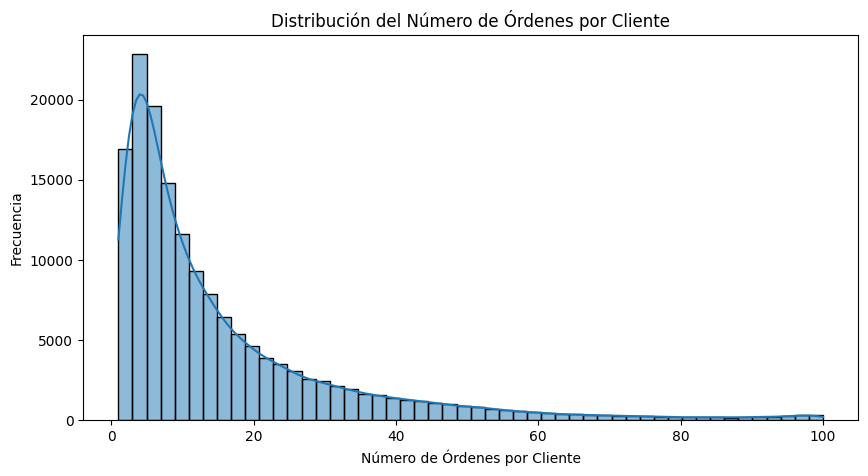

Estadísticas de órdenes por cliente:
Promedio de órdenes por cliente: 15.58
Mediana de órdenes por cliente: 9
Máximo número de órdenes hechas por un cliente: 100


In [7]:
# Verificar que la columna 'user_id' y 'order_number' están en dim_orders_df
if "user_id" in dim_orders_df.columns and "order_number" in dim_orders_df.columns:
    # Contar cuántas órdenes ha hecho cada cliente
    orders_per_customer = dim_orders_df.groupby("user_id")["order_number"].max()

    # Calcular estadísticas
    avg_orders = orders_per_customer.mean()
    median_orders = orders_per_customer.median()
    max_orders = orders_per_customer.max()

    # Crear histograma de la distribución de órdenes por cliente
    plt.figure(figsize=(10, 5))
    sns.histplot(orders_per_customer, bins=50, kde=True, palette="viridis")

    # Configuración del gráfico
    plt.xlabel("Número de Órdenes por Cliente")
    plt.ylabel("Frecuencia")
    plt.title("Distribución del Número de Órdenes por Cliente")

    # Mostrar el gráfico
    plt.show()

    # Imprimir métricas
    print(f"Estadísticas de órdenes por cliente:")
    print(f"Promedio de órdenes por cliente: {avg_orders:.2f}")
    print(f"Mediana de órdenes por cliente: {median_orders:.0f}")
    print(f"Máximo número de órdenes hechas por un cliente: {max_orders}")

else:
    print(" Las columnas 'user_id' y/o 'order_number' no están presentes en DIM_ORDERS.")


5. Top 20 productos más frecuentes


/tmp/ipykernel_2611/2449552759.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


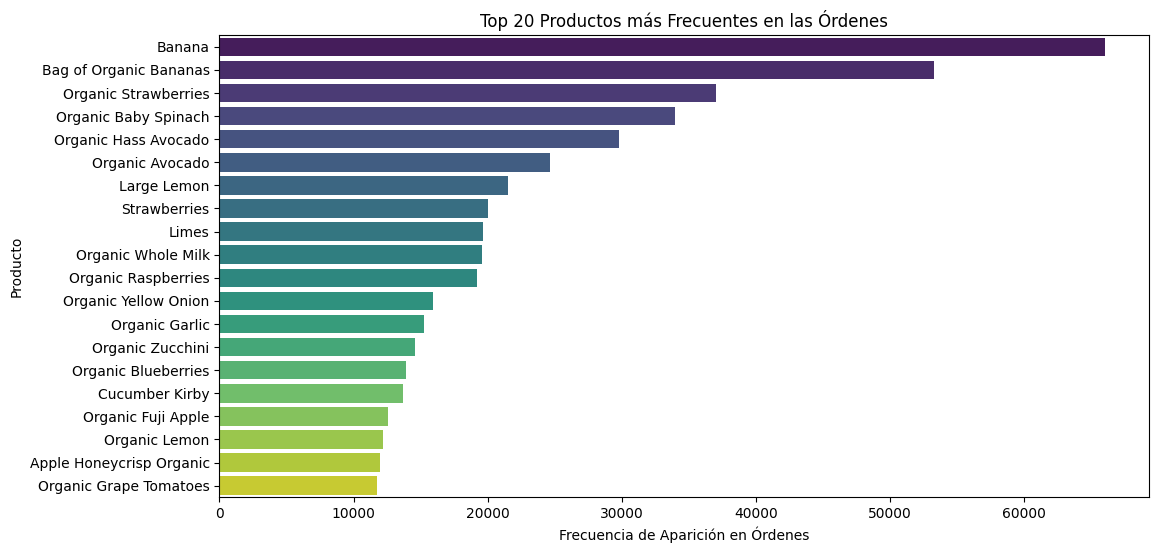

Top 20 productos más frecuentes en órdenes:


,product_id,order_count,product_name,aisle_id,department_id
0,24852,66050,Banana,24,4
1,13176,53297,Bag of Organic Bananas,24,4
2,21137,37039,Organic Strawberries,24,4
3,21903,33971,Organic Baby Spinach,123,4
4,47209,29773,Organic Hass Avocado,24,4
5,47766,24689,Organic Avocado,24,4
6,47626,21495,Large Lemon,24,4
7,16797,20018,Strawberries,24,4
8,26209,19690,Limes,24,4
9,27845,19600,Organic Whole Milk,84,16


In [8]:
# Verificar que las columnas 'product_id' están en fact_orders_df y 'product_name' en dim_products_df
if "product_id" in fact_orders_df.columns and "product_id" in dim_products_df.columns and "product_name" in dim_products_df.columns:
    # Contar la cantidad de veces que cada producto aparece en las órdenes
    product_counts = fact_orders_df["product_id"].value_counts().reset_index()
    product_counts.columns = ["product_id", "order_count"]

    # Unir con dim_products para obtener los nombres de los productos
    top_products = product_counts.merge(dim_products_df, on="product_id").head(20)

    # Crear gráfico de barras
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=top_products["order_count"], 
        y=top_products["product_name"], 
        palette="viridis"
    )

    # Configuración del gráfico
    plt.xlabel("Frecuencia de Aparición en Órdenes")
    plt.ylabel("Producto")
    plt.title("Top 20 Productos más Frecuentes en las Órdenes")
    
    # Mostrar el gráfico
    plt.show()

    # Imprimir tabla con los datos
    print("Top 20 productos más frecuentes en órdenes:")
    display(top_products)

else:
    print("No se encontraron las columnas 'product_id' en FACT_ORDERS o 'product_name' en DIM_PRODUCTS.")

6. ¿Cuántos artículos se compran generalmente en un pedido?


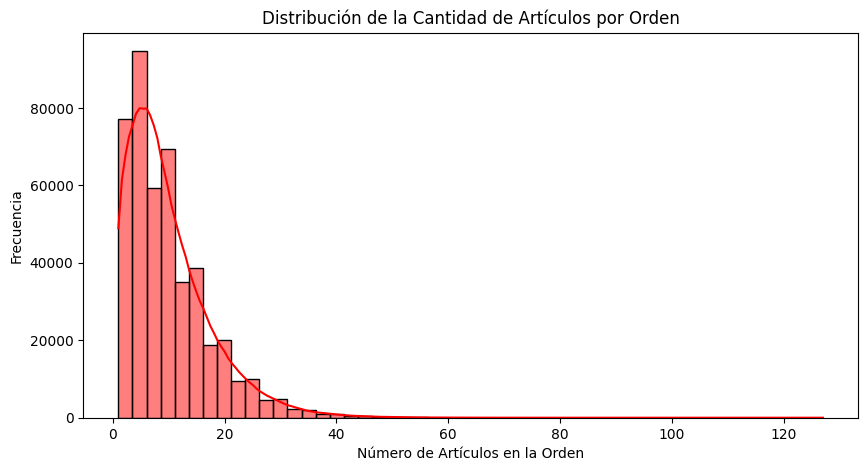

Estadísticas sobre la cantidad de artículos por orden:
Promedio de artículos por orden: 10.10
Mediana de artículos por orden: 8.00
Máximo de artículos en una orden: 127
Mínimo de artículos en una orden: 1


In [9]:
# Verificar que la columna 'order_id' está en fact_orders_df
if "order_id" in fact_orders_df.columns:
    # Contar la cantidad de productos por cada orden
    items_per_order = fact_orders_df["order_id"].value_counts()

    # Crear el histograma
    plt.figure(figsize=(10, 5))
    sns.histplot(items_per_order, bins=50, kde=True, color="red")

    # Configuración del gráfico
    plt.xlabel("Número de Artículos en la Orden")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de la Cantidad de Artículos por Orden")

    # Mostrar el gráfico
    plt.show()

    # Cálculo de estadísticas descriptivas
    print("Estadísticas sobre la cantidad de artículos por orden:")
    print(f"Promedio de artículos por orden: {items_per_order.mean():.2f}")
    print(f"Mediana de artículos por orden: {items_per_order.median():.2f}")
    print(f"Máximo de artículos en una orden: {items_per_order.max()}")
    print(f"Mínimo de artículos en una orden: {items_per_order.min()}")

else:
    print("La columna 'order_id' no está presente en FACT_ORDERS.")

7. Top 20 artículos que se vuelven a pedir con más frecuencia


/tmp/ipykernel_2611/1428217712.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reordered_products.values, y=top_product_names, palette="viridis")


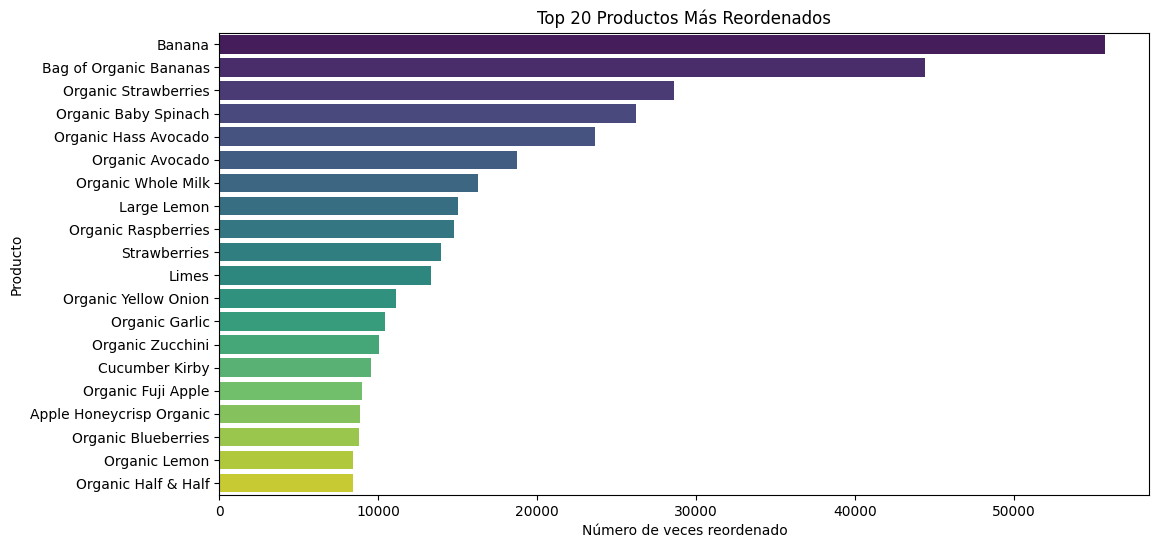

Top 20 Productos Más Reordenados:


,Producto,Cantidad de Reordenes
product_id,,
24852,Banana,55763
13176,Bag of Organic Bananas,44450
21137,Organic Strawberries,28639
21903,Organic Baby Spinach,26233
47209,Organic Hass Avocado,23629
47766,Organic Avocado,18743
27845,Organic Whole Milk,16251
47626,Large Lemon,15044
27966,Organic Raspberries,14748


In [10]:
# Verificar que las columnas necesarias están en fact_orders_df
if "product_id" in fact_orders_df.columns and "is_reordered" in fact_orders_df.columns:
    # Filtrar solo los productos que han sido reordenados al menos una vez
    reordered_products = fact_orders_df[fact_orders_df["is_reordered"] == 1]

    # Contar la frecuencia de reorden por producto
    top_reordered_products = reordered_products["product_id"].value_counts().head(20)

    # Obtener los nombres de los productos desde la tabla dim_products
    top_product_names = dim_products_df.set_index("product_id").loc[top_reordered_products.index]["product_name"]

    # Crear el gráfico de barras
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_reordered_products.values, y=top_product_names, palette="viridis")

    # Configuración del gráfico
    plt.xlabel("Número de veces reordenado")
    plt.ylabel("Producto")
    plt.title("Top 20 Productos Más Reordenados")

    # Mostrar el gráfico
    plt.show()

    # Mostrar los datos en formato tabla
    print("Top 20 Productos Más Reordenados:")
    display(pd.DataFrame({"Producto": top_product_names, "Cantidad de Reordenes": top_reordered_products.values}))

else:
    print("Las columnas 'product_id' y/o 'is_reordered' no están presentes en FACT_ORDERS.")

8. Proporción de pedidos que se vuelven a pedir para cada producto


/tmp/ipykernel_2611/3766912027.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reorder_ratio.values, y=top_product_names, palette="viridis")


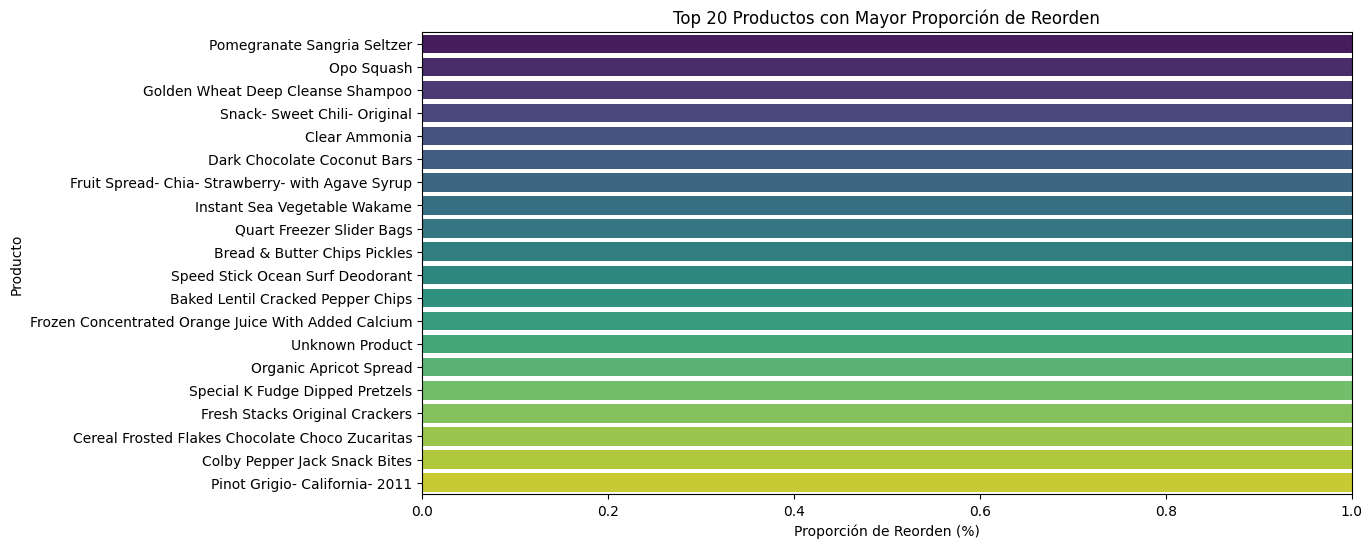

Top 20 Productos con Mayor Proporción de Reorden:


,Producto,Proporción de Reorden
product_id,,
29146,Pomegranate Sangria Seltzer,1.0
49619,Opo Squash,1.0
49625,Golden Wheat Deep Cleanse Shampoo,1.0
24896,Snack- Sweet Chili- Original,1.0
24901,Clear Ammonia,1.0
24839,Dark Chocolate Coconut Bars,1.0
23309,Fruit Spread- Chia- Strawberry- with Agave Syrup,1.0
4784,Instant Sea Vegetable Wakame,1.0
40959,Quart Freezer Slider Bags,1.0


In [11]:

# Verificar que las columnas necesarias están en fact_orders_df
if "product_id" in fact_orders_df.columns and "is_reordered" in fact_orders_df.columns:
    # Calcular el total de órdenes por producto
    total_orders_per_product = fact_orders_df["product_id"].value_counts()

    # Calcular el total de veces que se ha reordenado cada producto
    reordered_counts = fact_orders_df[fact_orders_df["is_reordered"] == 1]["product_id"].value_counts()

    # Calcular la proporción de reorden
    reorder_ratio = (reordered_counts / total_orders_per_product).fillna(0)

    # Obtener el top 20 productos con mayor proporción de reorden
    top_reorder_ratio = reorder_ratio.sort_values(ascending=False).head(20)

    # Obtener los nombres de los productos desde la tabla dim_products
    top_product_names = dim_products_df.set_index("product_id").loc[top_reorder_ratio.index]["product_name"]

    # Crear el gráfico de barras
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_reorder_ratio.values, y=top_product_names, palette="viridis")

    # Configuración del gráfico
    plt.xlabel("Proporción de Reorden (%)")
    plt.ylabel("Producto")
    plt.title("Top 20 Productos con Mayor Proporción de Reorden")
    plt.xlim(0, 1)  # La proporción está entre 0 y 1

    # Mostrar el gráfico
    plt.show()

    # Mostrar los datos en formato tabla
    print("Top 20 Productos con Mayor Proporción de Reorden:")
    display(pd.DataFrame({
        "Producto": top_product_names,
        "Proporción de Reorden": top_reorder_ratio.values
    }))

else:
    print("Las columnas 'product_id' y/o 'is_reordered' no están presentes en FACT_ORDERS.")


9. Proporción de productos pedidos que se vuelven a pedir para cada cliente


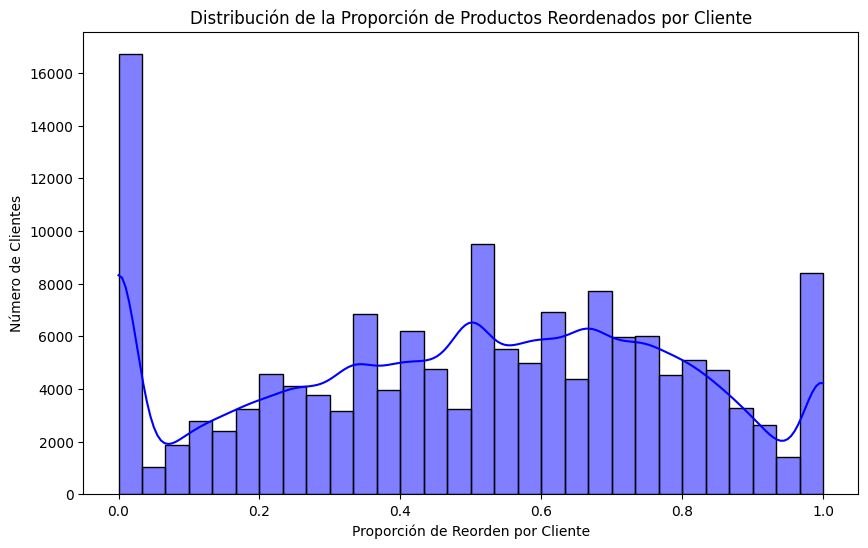

Estadísticas de la Proporción de Reorden por Cliente:
count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: count, dtype: float64

Top 20 Clientes con Mayor Proporción de Reorden:


,Proporción de Reorden
user_id,
181494,1.0
68,1.0
181487,1.0
48553,1.0
48482,1.0
178,1.0
104,1.0
206164,1.0
206120,1.0


In [12]:

# Verificar que las columnas necesarias están en dim_orders_df y fact_orders_df
if "order_id" in dim_orders_df.columns and "user_id" in dim_orders_df.columns and "order_id" in fact_orders_df.columns and "is_reordered" in fact_orders_df.columns:
    # Unir las tablas para obtener el user_id en fact_orders_df
    merged_df = fact_orders_df.merge(dim_orders_df[["order_id", "user_id"]], on="order_id", how="left")

    # Calcular el total de productos comprados por cada cliente
    total_products_per_user = merged_df["user_id"].value_counts()

    # Calcular el total de productos reordenados por cada cliente
    reordered_products_per_user = merged_df[merged_df["is_reordered"] == 1]["user_id"].value_counts()

    # Calcular la proporción de productos reordenados por cliente
    reorder_ratio_per_user = (reordered_products_per_user / total_products_per_user).fillna(0)

    # Crear el histograma de la proporción de reorden por cliente
    plt.figure(figsize=(10, 6))
    sns.histplot(reorder_ratio_per_user, bins=30, kde=True, color="blue")

    # Configuración del gráfico
    plt.xlabel("Proporción de Reorden por Cliente")
    plt.ylabel("Número de Clientes")
    plt.title("Distribución de la Proporción de Productos Reordenados por Cliente")

    # Mostrar el gráfico
    plt.show()

    # Mostrar las estadísticas clave
    print("Estadísticas de la Proporción de Reorden por Cliente:")
    print(reorder_ratio_per_user.describe())

    # Mostrar los clientes con la mayor proporción de reorden
    top_reorder_users = reorder_ratio_per_user.sort_values(ascending=False).head(20)
    print("\nTop 20 Clientes con Mayor Proporción de Reorden:")
    display(top_reorder_users.to_frame(name="Proporción de Reorden"))

else:
    print("No se encontraron las columnas necesarias en DIM_ORDERS y/o FACT_ORDERS.")


10. Top 20 artículos que la gente pone primero en el carrito


/tmp/ipykernel_2611/615663217.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


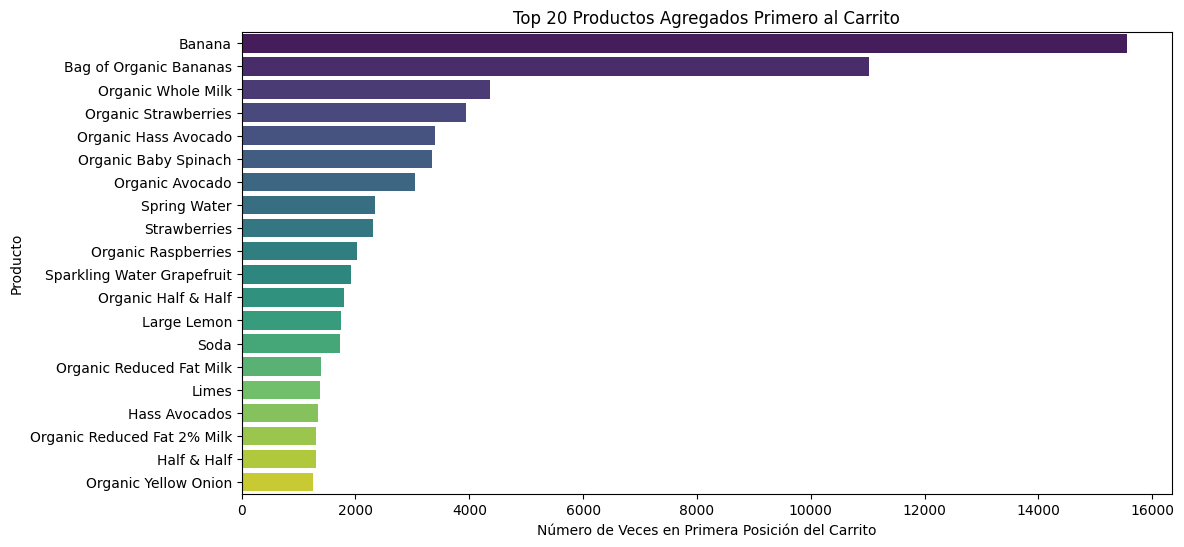

Top 20 Productos Más Comunes en Primera Posición del Carrito:


,product_id,count,product_name
0,24852,15562,Banana
1,13176,11026,Bag of Organic Bananas
2,27845,4363,Organic Whole Milk
3,21137,3946,Organic Strawberries
4,47209,3390,Organic Hass Avocado
5,21903,3336,Organic Baby Spinach
6,47766,3044,Organic Avocado
7,19660,2336,Spring Water
8,16797,2308,Strawberries
9,27966,2024,Organic Raspberries


In [13]:
# Verificar que las columnas necesarias están en fact_orders_df y dim_products_df
if "product_id" in fact_orders_df.columns and "cart_order" in fact_orders_df.columns:
    # Filtrar solo los productos que fueron agregados en primera posición (cart_order = 1)
    first_cart_products = fact_orders_df[fact_orders_df["cart_order"] == 1]

    # Contar la frecuencia con la que cada producto aparece en primera posición
    first_cart_product_counts = first_cart_products["product_id"].value_counts().head(20)

    # Unir con dim_products_df para obtener los nombres de los productos
    top_first_cart_products = first_cart_product_counts.reset_index()
    top_first_cart_products.columns = ["product_id", "count"]
    top_first_cart_products = top_first_cart_products.merge(dim_products_df[["product_id", "product_name"]],
                                                             on="product_id", how="left")

    # Crear el gráfico de barras
    plt.figure(figsize=(12, 6))
    sns.barplot(
        y=top_first_cart_products["product_name"],
        x=top_first_cart_products["count"],
        palette="viridis"
    )

    # Configuración del gráfico
    plt.xlabel("Número de Veces en Primera Posición del Carrito")
    plt.ylabel("Producto")
    plt.title("Top 20 Productos Agregados Primero al Carrito")
    
    # Mostrar el gráfico
    plt.show()

    # Mostrar los datos en formato tabla
    print("Top 20 Productos Más Comunes en Primera Posición del Carrito:")
    display(top_first_cart_products)

else:
    print("Las columnas 'product_id' y/o 'cart_order' no están presentes en FACT_ORDERS.")